# Optimización Bayesiana

**Teorema de Bayes**

$$ P(A|B) = \frac{P(B|A) P(A)}{P(B)} $$

$ P(A|B) $: Probabilidad condicional de A dado B. También conocida como la probabilidad posterior de A dado que B ocurre.

$ P(B|A) $: Probabilidad condicional de B dado A. Se interpreta como la verosimilitud (*likelihood*) de A.

$ P(A) $: Probabilidad de observar A. También conocida como probabilidad a priori.

$ P(B) $: Probabilidad de observar B. Interpretada como evidencia.

Utilizando las definiciones de arriba actualizamos la definición del teorema de bayes:

$$ \text{posterior} = \frac{(\text{verosimilitud})(\text{anterior})}{\text{evidencia}} $$

La intuición es que el teorema de Bayes es una herramienta para actualizar nuestras creencias dado lo que se tenía antes y nueva evidencia. Por ejemplo, tomas una moneda y asumes que es una moneda justa, dado que es lo más probable y que las monedas suelen ser justas en tu experiencia. Lanzas la moneda tres veces y cae sello las tres veces; un poco extraño, así que ajustas tus creencias y empiezas a imaginar que la moneda no es tan justa como debería ser. Lanzas las monedas tres veces y cae águila; ahora crees que la moneda es justa de nuevo.

## ¿Cómo aplicamos esto en nuestra vida diaria?

Imagina que tienes 3 puntos (conocimiento previo) en un espacio.

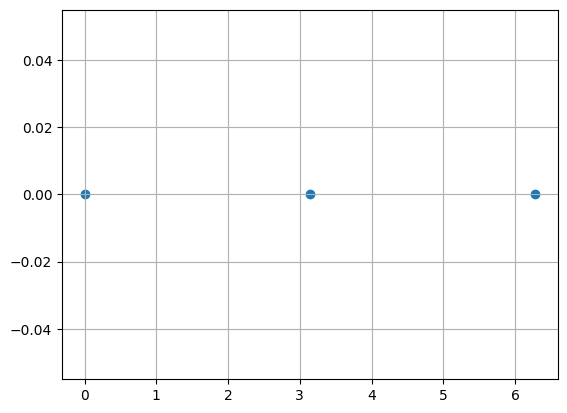

In [1]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(); plt.scatter([0, np.pi, 2*np.pi], [0, 0, 0]); plt.grid()

No hay seguridad de cómo se conectan estos puntos, pero sabes que están conectados. Hay infinitas formas en las que estos puntos se pueden conectar.

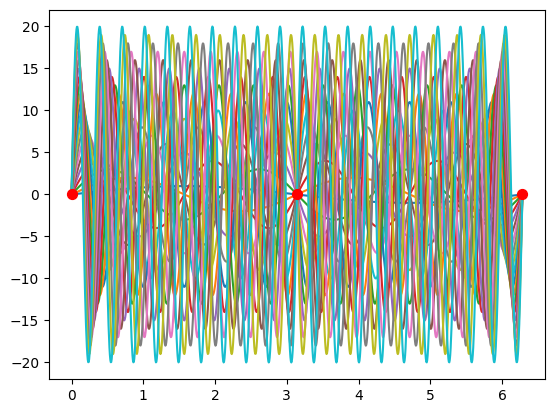

In [2]:
x = np.linspace(0, 2*np.pi, 1000); plt.figure(); 
for i in range(20) :
    y = (i+1)*np.sin((i+1)*x); plt.plot(x, y)
plt.scatter([0, np.pi, 2*np.pi], [0, 0, 0], s=50, c="r", zorder=3)

Hay tanta incertidumbre que decides pedir más información y te dan otro punto.

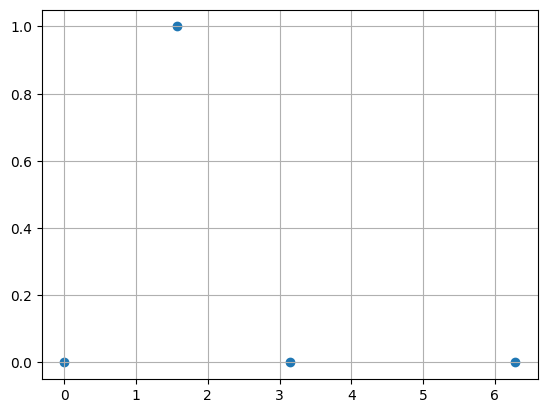

In [3]:
plt.figure(); plt.scatter([0, np.pi, 2*np.pi, np.pi/2], [0, 0, 0, 1]); plt.grid()

Con esta nueva información actualizas tus creencias y reduces la cantidad de formas en las que se conectan estos puntos (siguen siendo infinitas).

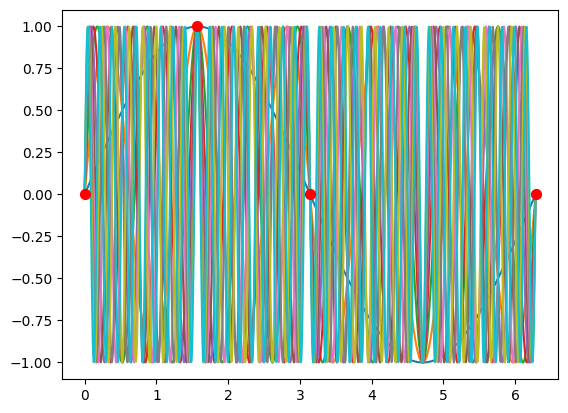

In [4]:
x = np.linspace(0, 2*np.pi, 1000); plt.figure(); 
for i in range(10) :
    y = np.sin((4*i+1)*x); plt.plot(x, y)
plt.scatter([0, np.pi, 2*np.pi, np.pi/2], [0, 0, 0, 1], s=50, c="r", zorder=3)

Te pones a pensar: "Sí. Teóricamente hay infinitas funciones que pueden conectar estos puntos, pero sólo algunas tienen sentido dado mi contexto."

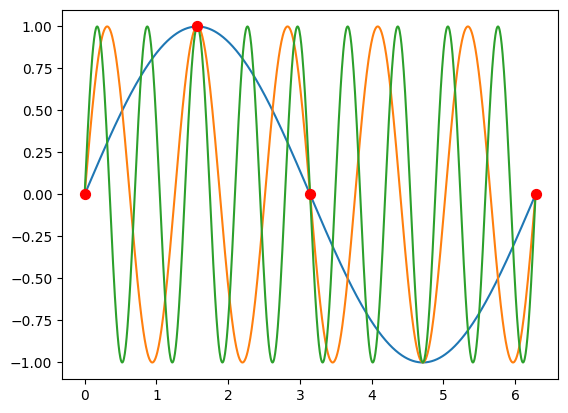

In [5]:
x = np.linspace(0, 2*np.pi, 1000); plt.figure(); 
for i in range(3) :
    y = np.sin((4*i+1)*x); plt.plot(x, y)
plt.scatter([0, np.pi, 2*np.pi, np.pi/2], [0, 0, 0, 1], s=50, c="r", zorder=3)

Ahora sólo quedan algunos pocos candidatos dado el criterio que tienes. Hay incertidumbre sobre cuál de estos candidatos podría ser el que mejor se ajusta, así que decides pedir más información. ¿Qué información serviría más?
- Se podría pedir el valor de $y$ cuando $x=\frac{3\pi}{2}$, pero los candidatos que tenemos todos pasan por el mismo punto. Incluso si nos dieran la información, no ayudaría de mucho.
- Se podría pedir fuera del rango que tenemos, pero quizás la información no existe o dado el contexto del problema es imposible que estos puntos existan.

Nos asignan nuestro último punto.

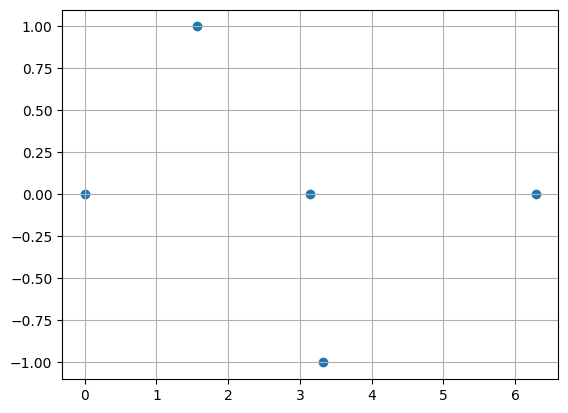

In [6]:
plt.figure(); plt.scatter([0, np.pi, 2*np.pi, np.pi/2, 19*np.pi/18], [0, 0, 0, 1, -1]); plt.grid()

Usamos esta nueva información (evidencia) junto con lo que conocíamos (anterior) y lo que creemos que es posible (verosimilitud) para decidir sobre una nueva función (posterior).

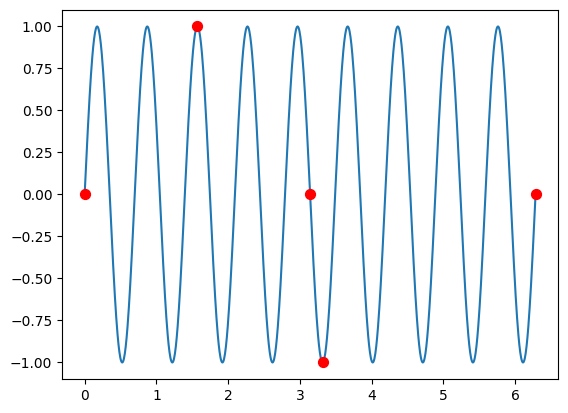

In [7]:
x = np.linspace(0, 2*np.pi, 1000); plt.figure(); y = np.sin(9*x); plt.plot(x, y)
plt.scatter([0, np.pi, 2*np.pi, np.pi/2, 19*np.pi/18], [0, 0, 0, 1, -1], s=50, c="r", zorder=3)

Una forma de realizar este experimento es mediante un proceso gaussiano, que asume que la variable de salida es una variable aleatoria con distribución normal multivariada. Utilicemos la función que encontramos y asumamos que no sabemos cuál es.

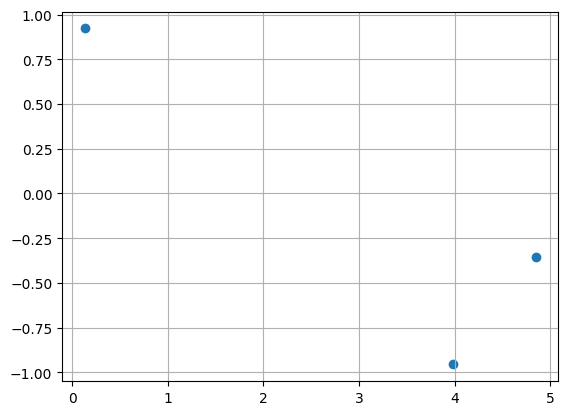

In [8]:
np.random.seed(10)
def f(x) :
    return np.sin(9*x)
X = np.random.uniform(0, 2*np.pi, 3).reshape([-1, 1])
plt.figure(); plt.scatter(X, f(X)); plt.grid()

Realizamos una regresión de proceso gaussiano para encontrar distribuciones que podrían darnos estas muestras

In [9]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# 1. Definir el Kernel
# El kernel RBF (Radial Basis Function) controla la suavidad de la curva.
# 'length_scale' determina qué tan "lejos" influye un punto sobre otro.
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))

# 2. Configurar el Modelo
# n_restarts_optimizer ayuda a encontrar los mejores hiperparámetros del kernel
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)

# 3. Ajustar el modelo a tus datos (X y f(X))
# Asegúrate de que f(X) sea un vector plano (1D)
y = f(X).ravel() 
gp.fit(X, y)

# 4. Generar predicciones en un rango nuevo (test)
X_test = np.linspace(0, 2*np.pi, 100).reshape(-1, 1)
y_mean, y_std = gp.predict(X_test, return_std=True)

Creamos un vector de valores posibles de $x$ y predecimos $y$ usando el resultado de la regresión.

In [10]:
# 1. Creamos el vector de valores posibles (el dominio de búsqueda)
# Usamos 100 o 500 puntos para que la curva se vea suave
x_test = np.linspace(0, 2*np.pi, 500).reshape(-1, 1)

# 2. Predecimos la media (y) y la desviación estándar (incertidumbre)
# 'return_std=True' es vital para la Optimización Bayesiana
y_mean, y_std = gp.predict(x_test, return_std=True)

Graficamos nuestra primera propuesta, utilizando el error estándar para dibujar nuestros intervalos de confianza.

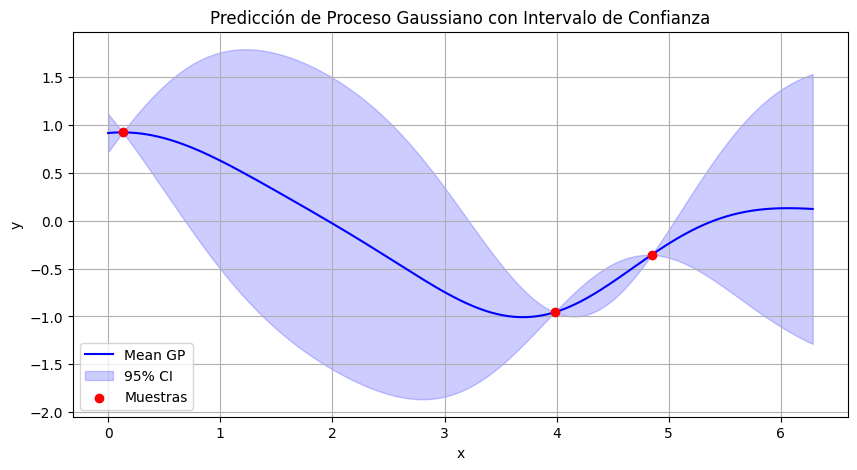

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(x_test, y_mean, color='blue', label='Mean GP')

# 3. Graficar el intervalo de confianza (el error estándar)
# .flatten() asegura que los arrays sean de una sola dimensión para matplotlib
plt.fill_between(
    x_test.ravel(),
    y_mean - 1.96 * y_std,
    y_mean + 1.96 * y_std,
    color='blue',
    alpha=0.2,
    label='95% CI'
)
plt.scatter(X, y, color='red', zorder=5, label='Muestras')
plt.title('Predicción de Proceso Gaussiano con Intervalo de Confianza')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

Podemos ver que necesitamos más muestras debido a que hay mucha incertidumbre en algunas partes de nuestro dominio. Hay varios criterios para decidir cómo pedir muestras:
- Maximizar (busco mi predicción del máximo actual y pido esa medida)
- Minimizar (busco mi predicción del mínimo actual y pido esa medida)
- Reducir incertidumbre (busco el punto donde mi intervalo de confianza es más grande y pido esa medida)

In [12]:
# 1. Maximizar: ¿Dónde cree el modelo que está el valor más alto?
idx_max = np.argmax(y_mean)
x_next_max = x_test[idx_max]

# 2. Minimizar: ¿Dónde cree el modelo que está el valor más bajo?
idx_min = np.argmin(y_mean)
x_next_min = x_test[idx_min]

# 3. Reducir Incertidumbre: ¿Dónde el modelo está más "confundido"?
# Buscamos el punto con la desviación estándar más alta
idx_uncertainty = np.argmax(y_std)
x_next_uncertainty = x_test[idx_uncertainty]

print(f"Propuesta para Maximizar: x = {x_next_max[0]:.4f}")
print(f"Propuesta para Minimizar: x = {x_next_min[0]:.4f}")
print(f"Propuesta para Explorar (Incertidumbre): x = {x_next_uncertainty[0]:.4f}")

Propuesta para Maximizar: x = 0.1259
Propuesta para Minimizar: x = 3.7019
Propuesta para Explorar (Incertidumbre): x = 1.9895


Y repetimos el proceso ya con nueva información.

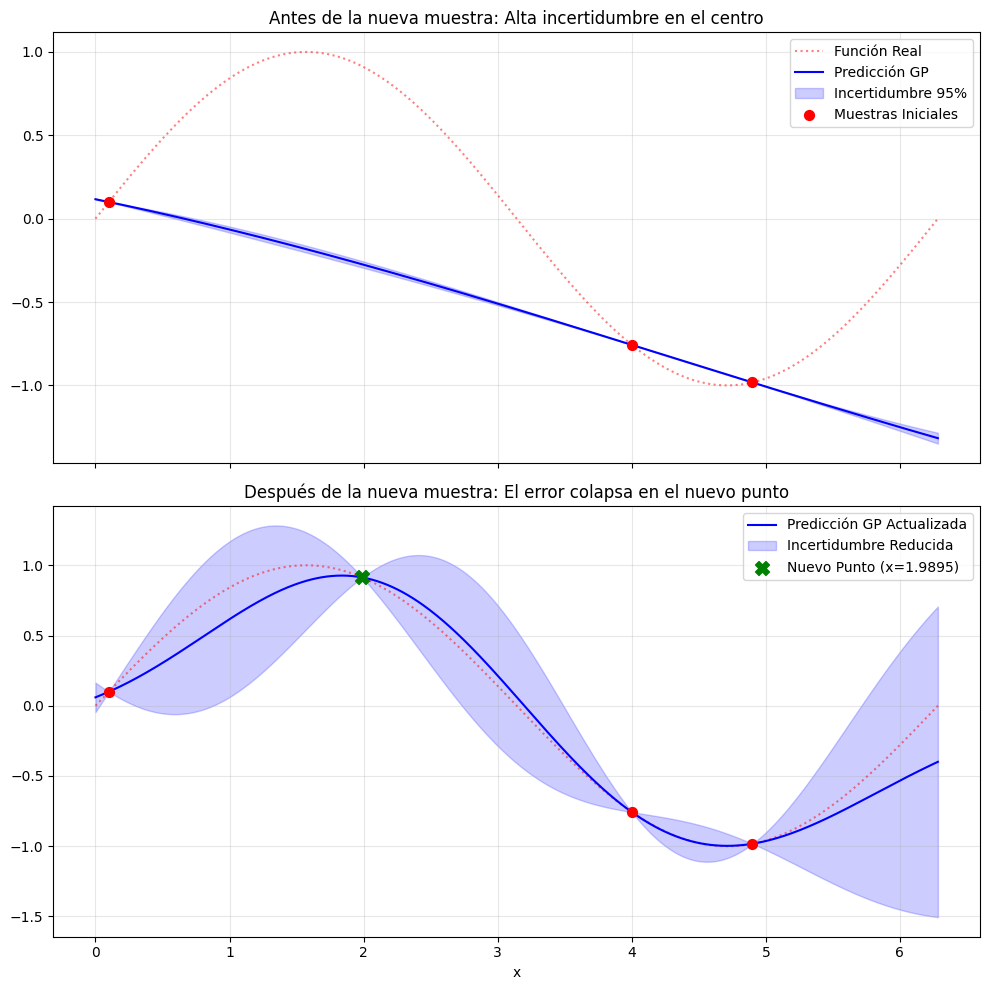

In [16]:
# 1. Definimos la función objetivo (ejemplo: seno)
def f(x):
    return np.sin(x)

# 2. Datos iniciales (3 puntos originales)
X_init = np.array([[0.1], [4.0], [4.9]])
y_init = f(X_init).flatten()

# 3. Configuración del Proceso Gaussiano (Kernel RBF)
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)

# --- PASO A: Ajuste Inicial ---
gp.fit(X_init, y_init)
x_test = np.linspace(0, 2*np.pi, 500).reshape(-1, 1)
y_mean_old, y_std_old = gp.predict(x_test, return_std=True)

# --- PASO B: Agregar nueva información (Punto de exploración x=1.9895) ---
x_nuevo = np.array([[1.9895]])
y_nuevo = f(x_nuevo).flatten()

X_final = np.vstack([X_init, x_nuevo])
y_final = np.concatenate([y_init, y_nuevo])

# Re-entrenamos el modelo con 4 puntos ahora
gp.fit(X_final, y_final)
y_mean_new, y_std_new = gp.predict(x_test, return_std=True)

# --- GRAFICACIÓN ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Gráfica 1: Estado Original
ax1.plot(x_test, f(x_test), 'r:', alpha=0.5, label='Función Real')
ax1.plot(x_test, y_mean_old, 'b-', label='Predicción GP')
ax1.fill_between(x_test.flatten(), y_mean_old - 1.96*y_std_old, 
                 y_mean_old + 1.96*y_std_old, alpha=0.2, color='blue', label='Incertidumbre 95%')
ax1.scatter(X_init, y_init, c='red', s=50, zorder=10, label='Muestras Iniciales')
ax1.set_title('Antes de la nueva muestra: Alta incertidumbre en el centro')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfica 2: Estado Actualizado
ax2.plot(x_test, f(x_test), 'r:', alpha=0.5)
ax2.plot(x_test, y_mean_new, 'b-', label='Predicción GP Actualizada')
ax2.fill_between(x_test.flatten(), y_mean_new - 1.96*y_std_new, 
                 y_mean_new + 1.96*y_std_new, alpha=0.2, color='blue', label='Incertidumbre Reducida')
ax2.scatter(X_init, y_init, c='red', s=50, zorder=10)
ax2.scatter(x_nuevo, y_nuevo, c='green', marker='X', s=100, zorder=11, label='Nuevo Punto (x=1.9895)')
ax2.set_title('Después de la nueva muestra: El error colapsa en el nuevo punto')
ax2.set_xlabel('x')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Repitamos el proceso 30 veces con una función distinta.

$$ f(x) = \sin{(\frac{x}{3})} + \cos{(2x)},\ \ \ \ x \in [-5\pi, 5\pi] $$

### Actividad

1. Modificar el comportamiento de selección para elegir el máximo de las predicciones como el siguiente punto.
2. Modificar el comportamiento de selección para elegir el mínimo de las predicciones como el siguiente punto.